# Data Cleaning

In [1]:
import pandas as pd

In [2]:
per_game = pd.read_csv("Player Per Game.csv")
advanced = pd.read_csv("Advanced.csv")
all_star = pd.read_csv("All-Star Selections.csv")

In [5]:
per_game.columns = per_game.columns.str.strip().str.lower()
advanced.columns = advanced.columns.str.strip().str.lower()
all_star.columns = all_star.columns.str.strip().str.lower()

In [6]:
df = pd.merge(
    per_game,
    advanced,
    on=["player_id", "season"],
    how="inner",
    suffixes=("_pg", "_adv")
)

all_star["allstar"] = 1

all_star_labels = all_star[["player_id", "season", "allstar"]].drop_duplicates()

df = pd.merge(
    df,
    all_star_labels,
    on=["player_id", "season"],
    how="left"
)

df["allstar"] = df["allstar"].fillna(0).astype(int)

In [7]:
print("===== DATASET STATISTICS =====\n")

print(f"Number of records: {df.shape[0]}")
print(f"Number of columns (including target): {df.shape[1]}")

print("\nFeature types:")
print(df.dtypes.value_counts())

print("\nMissing values by column (top 15):")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nClass distribution:")
print(df["allstar"].value_counts())

print("\nClass distribution (%):")
print((df["allstar"].value_counts(normalize=True) * 100).round(2))

print("\nColumns:")
print(df.columns.tolist())

===== DATASET STATISTICS =====

Number of records: 52984
Number of columns (including target): 61

Feature types:
float64    48
object      9
int64       4
Name: count, dtype: int64

Missing values by column (top 15):
x3p_percent      17527
gs_pg            13118
gs_adv           13067
x2p_percent      10432
x3p_ar           10251
e_fg_percent     10250
x3pa_per_game     9959
x2pa_per_game     9958
x2p_per_game      9958
x3p_per_game      9958
dbpm              9211
obpm              9211
bpm               9211
vorp              9201
stl_percent       9154
dtype: int64

Class distribution:
allstar
0    50526
1     2458
Name: count, dtype: int64

Class distribution (%):
allstar
0    95.36
1     4.64
Name: proportion, dtype: float64

Columns:
['season', 'lg_pg', 'player_pg', 'player_id', 'age_pg', 'team_pg', 'pos_pg', 'g_pg', 'gs_pg', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent',

# Exploratory Data Analysis

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

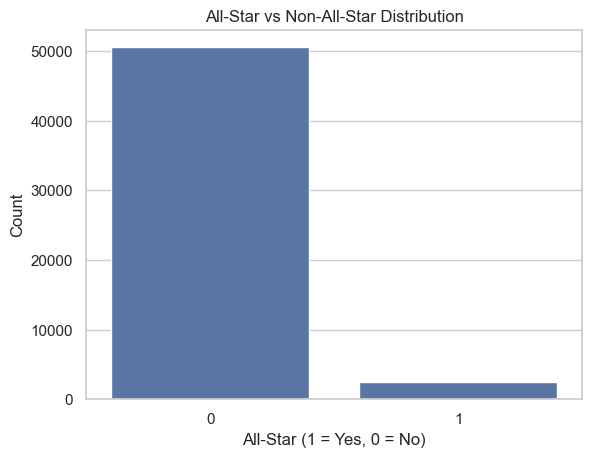

In [9]:
sns.countplot(x="allstar", data=df)
plt.title("All-Star vs Non-All-Star Distribution")
plt.xlabel("All-Star (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

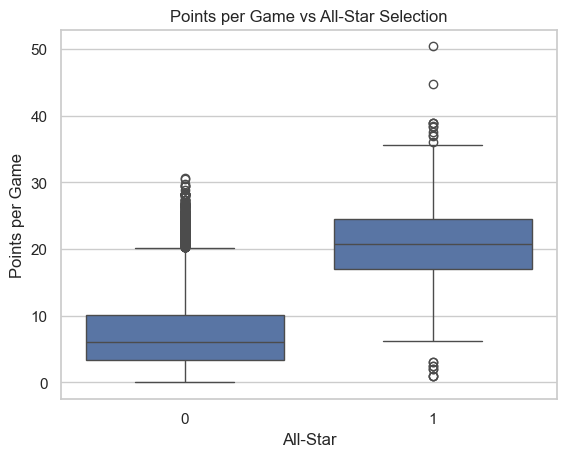

In [11]:
sns.boxplot(x="allstar", y="pts_per_game", data=df)
plt.title("Points per Game vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Points per Game")
plt.show()

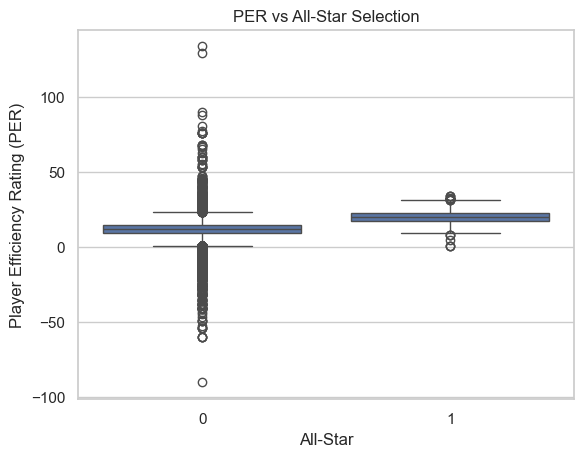

In [12]:
sns.boxplot(x="allstar", y="per", data=df)
plt.title("PER vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Player Efficiency Rating (PER)")
plt.show()

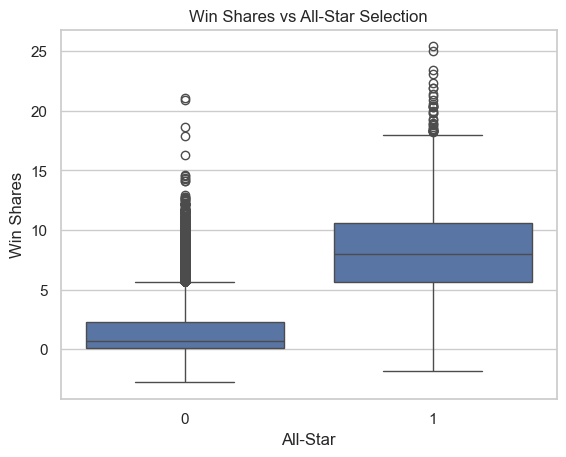

In [13]:
sns.boxplot(x="allstar", y="ws", data=df)
plt.title("Win Shares vs All-Star Selection")
plt.xlabel("All-Star")
plt.ylabel("Win Shares")
plt.show()

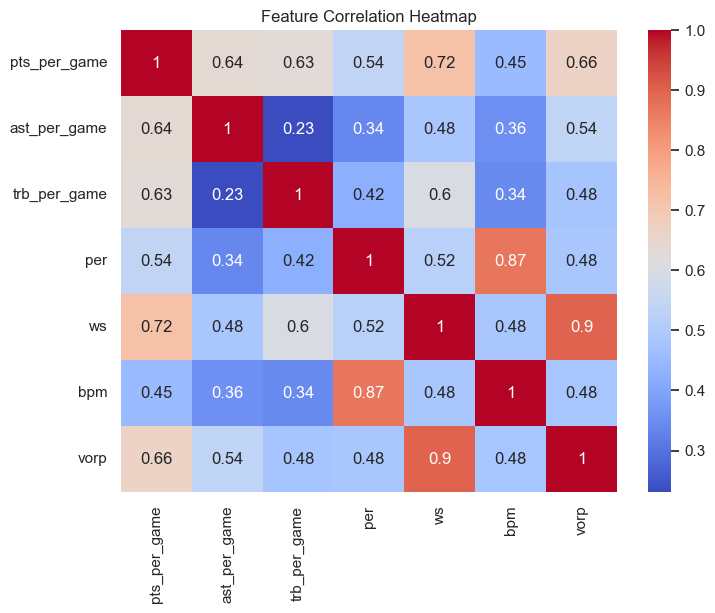

In [17]:
features = ["pts_per_game", "ast_per_game", "trb_per_game", "per", "ws", "bpm", "vorp"]

corr = df[features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

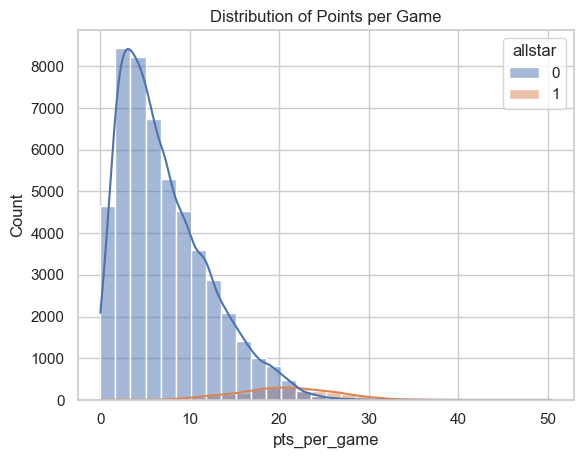

In [19]:
sns.histplot(data=df, x="pts_per_game", hue="allstar", bins=30, kde=True)
plt.title("Distribution of Points per Game")
plt.show()

testsdfsdf